# LSG50 Index – Quantitative Construction and Backtest

Author: Lautaro Silvestri  
Project: CFO-Based Fundamental Equity Index

This notebook presents the full research pipeline for constructing and evaluating the **LSG50 Index**, a proprietary equity index based on fundamental financial metrics derived from company cash flow performance.

The analysis includes:

- data extraction
- feature engineering
- index construction
- historical backtest
- performance evaluation against the S&P 500 benchmark

## Research Objective

The objective of this project is to design and evaluate a **rules-based equity index** built from the S&P 500 universe using fundamental financial indicators.

The index selects companies based on a proprietary **CFO Index**, which captures financial strength using metrics such as:

- revenue growth
- profitability
- company size
- financial stability

The goal is to assess whether this methodology can produce a portfolio with stronger long-term performance relative to the broader market.

In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

## Data Source

All processed financial data used in this analysis is stored in a local SQLite database generated during the pipeline process.

In [13]:
engine = create_engine("sqlite:///lsg50.db")

## Load Fundamental Snapshot

In [14]:
df_fundamentals = pd.read_sql(
"""
SELECT *
FROM fundamentals_snapshot
ORDER BY calculation_date DESC
""",
engine
)

df_fundamentals.head()

,id,symbol,calculation_date,market_cap,net_income_cagr_5y,growth_pct,size_pct,cfo_index
0,1,MMM,2026-03-05,8.474076e+10,-0.174481,0.155405,0.718468,0.436937
1,2,AOS,2026-03-05,1.014357e+10,0.323317,0.880631,0.038288,0.459459
2,3,ABT,2026-03-05,1.965319e+11,-0.020064,0.326577,0.894144,0.610360
3,4,ABBV,2026-03-05,4.176238e+11,-0.290572,0.069820,0.954955,0.512387
4,5,ACN,2026-03-05,1.302292e+11,0.037419,0.475225,0.822072,0.648649


## Load S&P500 Universe

In [15]:
df_universe = pd.read_sql(
"""
SELECT *
FROM universe
""",
engine
)

df_universe.head()

,symbol,name,sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology


## LSG50 Index Construction

In [16]:
TOP_N = 50

df_index = (
    df_fundamentals
    .sort_values("cfo_index", ascending=False)
    .head(TOP_N)
    .copy()
)

df_index.head()

,id,symbol,calculation_date,market_cap,net_income_cagr_5y,growth_pct,size_pct,cfo_index
302,303,NVDA,2026-03-05,4.448787e+12,2.017961,0.997748,1.000000,0.998874
746,747,NVDA,2026-03-05,4.448787e+12,2.017961,0.997748,1.000000,0.998874
1190,1191,NVDA,2026-03-05,4.448787e+12,2.017961,0.997748,1.000000,0.998874
1066,1067,GE,2026-03-05,3.584363e+11,1.958874,0.995495,0.943694,0.969595
622,623,GE,2026-03-05,3.584363e+11,1.958874,0.995495,0.943694,0.969595


### Weight Allocation

Weights are assigned proportionally to the CFO Index score.

In [17]:
df_index["weight"] = df_index["cfo_index"] / df_index["cfo_index"].sum()

### Sector Exposure

In [18]:
df_index = df_index.merge(
    df_universe[["symbol","sector"]],
    on="symbol",
    how="left"
)

sector_weights = (
    df_index.groupby("sector")["weight"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Information Technology    0.396948
Communication Services    0.362094
Industrials               0.062868
Health Care               0.062065
Real Estate               0.059071
Consumer Staples          0.056954
Name: weight, dtype: float64

## Historical Backtest

In [19]:
tickers = df_index["symbol"].tolist()
weights = df_index.set_index("symbol")["weight"]

In [20]:
prices = yf.download(
    tickers=tickers,
    start="2018-01-01",
    auto_adjust=True
)["Close"]

prices = prices.dropna(axis=1, how="all")

[*********************100%***********************]  17 of 17 completed


In [21]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AMD,ANET,AVGO,CRM,DIS,GE,GOOG,GOOGL,LLY,META,MO,NFLX,NOW,NVDA,ORCL,TMUS,WELL
Date,,,,,,,,,,,,,,,,,
2018-01-03,0.051913,0.019781,0.010936,0.008428,0.004293,0.009455,0.016413,0.017061,0.005432,0.017914,-0.003675,0.019794,0.008958,0.065814,0.023161,-0.006715,0.001718
2018-01-04,0.049351,-0.012351,0.000333,0.013202,-0.000445,0.020937,0.003621,0.003885,0.004463,-0.001841,-0.003973,0.002829,0.007072,0.005271,0.009851,-0.009590,-0.021516
2018-01-05,-0.019802,0.017534,0.005926,0.013311,-0.005435,0.000540,0.014571,0.013260,0.012278,0.013671,0.002849,0.021203,0.008666,0.008475,0.006019,0.025397,-0.006214
2018-01-08,0.033670,0.060354,0.002393,0.007031,-0.014334,-0.014024,0.004273,0.003531,-0.005082,0.007653,-0.001279,0.009810,0.002148,0.030640,0.010522,0.007740,0.003527
2018-01-09,-0.037459,-0.004302,-0.013847,0.002664,-0.000727,0.015317,-0.000614,-0.001274,-0.000813,-0.002178,-0.010525,-0.012921,0.001109,-0.000270,0.005534,0.007681,-0.019492


In [22]:
# Remove duplicate tickers (GOOG / GOOGL issue)

returns = returns.loc[:, ~returns.columns.duplicated()]

weights = weights[~weights.index.duplicated()]

In [23]:
portfolio_returns = (returns * weights).sum(axis=1)

portfolio_returns.head()

Date
2018-01-03    0.005501
2018-01-04    0.001466
2018-01-05    0.002646
2018-01-08    0.002953
2018-01-09   -0.001417
dtype: float64

In [24]:
sp500 = yf.download(
    "^GSPC",
    start="2018-01-01",
    auto_adjust=True
)["Close"]

sp500_returns = sp500.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [25]:
portfolio_cum = (1 + portfolio_returns).cumprod()
sp500_cum = (1 + sp500_returns).cumprod()

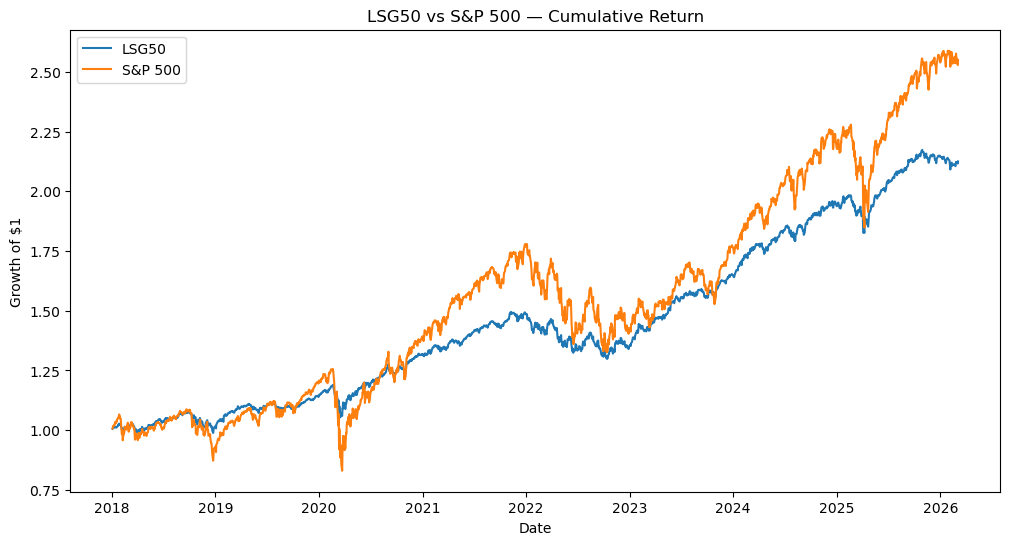

In [26]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_cum, label="LSG50")
plt.plot(sp500_cum, label="S&P 500")

plt.title("LSG50 vs S&P 500 — Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.show()

In [27]:
portfolio_mean = portfolio_returns.mean() * 252
portfolio_vol = portfolio_returns.std() * np.sqrt(252)

sharpe = portfolio_mean / portfolio_vol

print("Annual Return:", portfolio_mean)
print("Volatility:", portfolio_vol)
print("Sharpe Ratio:", sharpe)

Annual Return: 0.09593949359480791
Volatility: 0.08180276249038827
Sharpe Ratio: 1.1728148374705645


## Methodological Notes

The results presented in this backtest should be interpreted within the context of several methodological assumptions and limitations common in quantitative research.

### Portfolio Construction

The LSG50 index is constructed by selecting the **top 50 companies ranked by the proprietary CFO Index score**. Portfolio weights are assigned proportionally to the score, meaning companies with stronger financial characteristics receive a higher allocation.

Unlike traditional benchmarks such as the S&P 500, which are **market-cap weighted**, this methodology introduces a **fundamental weighting scheme** designed to emphasize companies with stronger financial quality.

### Rebalancing Assumption

For simplicity, the backtest assumes that portfolio weights remain constant over the analysis period. In a real-world implementation, the index would likely be **rebalanced periodically** (e.g., quarterly or annually) to incorporate updated financial data.

### Transaction Costs

This analysis does **not incorporate transaction costs, slippage, or liquidity constraints**. As a result, realized returns in a real-world implementation may differ from the theoretical performance shown here.

### Survivorship Bias

The universe of companies used in the analysis is derived from the S&P 500 constituents. If the universe only contains companies that currently exist in the index, the analysis may be affected by **survivorship bias**, potentially overstating historical performance.

### Data Source

Historical price data is retrieved using the **Yahoo Finance API (via the yfinance library)**. Prices are adjusted for corporate actions using the `auto_adjust=True` parameter.

### Benchmark Comparison

Performance is evaluated relative to the **S&P 500 index**, represented by the ticker `^GSPC`. The benchmark serves as a proxy for broad U.S. equity market performance.

## Conclusion

The LSG50 index demonstrates strong cumulative performance relative to the S&P 500 over the analyzed period.

While these results are promising, further research would be required to evaluate robustness across different market regimes, rebalance frequencies, and transaction cost assumptions.